In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df=pd.read_csv(r"/content/drive/MyDrive/Dataset/sentiment-emotion-labelled_Dell_tweets.csv")
df.head()


,Unnamed: 0,Datetime,Tweet Id,Text,Username,sentiment,sentiment_score,emotion,emotion_score
0,0,2022-09-30 23:29:15+00:00,1575991191170342912,@Logitech @apple @Google @Microsoft @Dell @Len...,ManjuSreedaran,neutral,0.853283,anticipation,0.587121
1,1,2022-09-30 21:46:35+00:00,1575965354425131008,@MK_habit_addict @official_stier @MortalKombat...,MiKeMcDnet,neutral,0.519470,joy,0.886913
2,2,2022-09-30 21:18:02+00:00,1575958171423752203,"As @CRN celebrates its 40th anniversary, Bob F...",jfollett,positive,0.763791,joy,0.960347
3,3,2022-09-30 20:05:24+00:00,1575939891485032450,@dell your customer service is horrible especi...,daveccarr,negative,0.954023,anger,0.983203
4,4,2022-09-30 20:03:17+00:00,1575939359160750080,@zacokalo @Dell @DellCares @Dell give the man ...,heycamella,neutral,0.529170,anger,0.776124


In [ ]:
#Selecting only the necessary columns
df = df[['Text', 'sentiment',]]

In [ ]:
#Renaming column 'Text' as 'test'
df.columns = ['text', 'sentiment']

In [ ]:
df = df.drop(['id', 'date', 'query','user_id'], axis = 1)
df.head()

KeyError: "['id', 'date', 'query', 'user_id'] not found in axis"

In [ ]:
display(df['sentiment'].value_counts())

,count
sentiment,
negative,10556
positive,7366
neutral,7048


In [ ]:
class_names=['negative','neutral','positive']
N=[0,1,2]
normal_mapping=dict(zip(class_names,N))
reverse_mapping=dict(zip(N,class_names))
df['sentiment']=df['sentiment'].map(normal_mapping)
display(df)

,text,sentiment
0,@Logitech @apple @Google @Microsoft @Dell @Len...,1
1,@MK_habit_addict @official_stier @MortalKombat...,1
2,"As @CRN celebrates its 40th anniversary, Bob F...",2
3,@dell your customer service is horrible especi...,0
4,@zacokalo @Dell @DellCares @Dell give the man ...,1
...,...,...
24965,@ElDarkAngel2 @GamersNexus @Dell I wouldn't ev...,0
24966,@kite_real @GamersNexus @Dell I didn't really ...,2
24967,Hey @JoshTheFixer here it is....27 4K UHD USB-...,1
24968,@bravadogaming @thewolfpena @Alienware @intel ...,1


In [ ]:
# Check the mapping
print(df['sentiment'].unique())


[1 2 0]


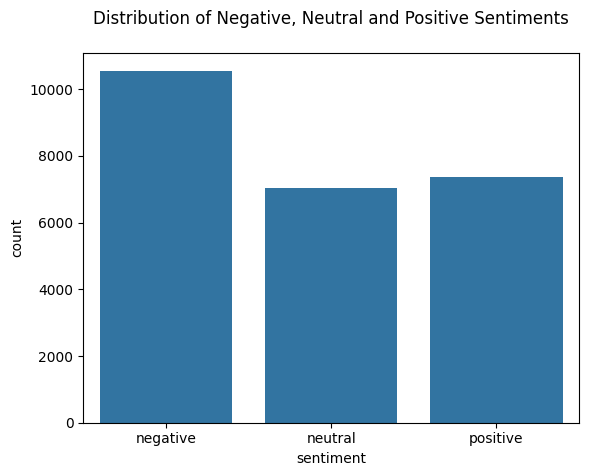

In [ ]:
# Distribution of positive and negative sentiments
ax = sns.countplot(x='sentiment', data=df)
# Get current tick locations and labels
tick_locs = ax.get_xticks()
tick_labels = [reverse_mapping[int(loc)] for loc in tick_locs]

# Set new tick locations and labels
ax.set_xticks(tick_locs)  # Set tick locations explicitly
ax.set_xticklabels(tick_labels)  # Set tick labels
plt.title('Distribution of Negative, Neutral and Positive Sentiments\n')
plt.show()

In [ ]:
# Removing URLs, Mentions and Websites
def remove_url_mention(text):
    # Define regex patterns
    url_pattern = r'https?://\S+|www\.\S+'
    mention_pattern = r'@\w+'
    site_pattern = r'\b\w+\.com\b'

    # Remove URLs, mentions, websites
    text = re.sub(url_pattern, '', text)
    text = re.sub(mention_pattern, '', text)
    text = re.sub(site_pattern, '', text)

    return text.strip()

df['wo_url'] = df['text'].apply(lambda text: remove_url_mention(text))


In [ ]:
# Remove Punctuations
translator = str.maketrans('', '', string.punctuation)

df['wo_punc'] = df['wo_url'].apply(lambda text: text.translate(translator))

In [ ]:
# Remove Stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in stop_words])

df["wo_stop"] = df["wo_punc"].apply(lambda text: remove_stopwords(text))

In [ ]:
# Apply Stemming
stemmer = PorterStemmer()
def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

df["cleaned_text"] = df["wo_stop"].apply(lambda text: stem_words(text))
print(df)

                                                    text  sentiment  \
0      @Logitech @apple @Google @Microsoft @Dell @Len...          1   
1      @MK_habit_addict @official_stier @MortalKombat...          1   
2      As @CRN celebrates its 40th anniversary, Bob F...          2   
3      @dell your customer service is horrible especi...          0   
4      @zacokalo @Dell @DellCares @Dell give the man ...          1   
...                                                  ...        ...   
24965  @ElDarkAngel2 @GamersNexus @Dell I wouldn't ev...          0   
24966  @kite_real @GamersNexus @Dell I didn't really ...          2   
24967  Hey @JoshTheFixer here it is....27 4K UHD USB-...          1   
24968  @bravadogaming @thewolfpena @Alienware @intel ...          1   
24969  @rabia_ejaz @Dell Stopped buying windows lapto...          2   

                                                  wo_url  \
0      #WhatIf QWERTY were modified for programmers s...   
1      She's getting a new 

In [ ]:
# Train-Test split
df_sampled = df
X = df_sampled['cleaned_text']
y = df_sampled['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(19976,)
(4994,)


In [ ]:
# Vectorization using TF-IDF
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

vocab_size = len(vectorizer.vocabulary_)
print(f'Vocabulary Size: {vocab_size}')

Vocabulary Size: 20421


INSTALLING LSTM/RNN


In [ ]:
!pip install keras-preprocessing # Correct package name for installation

# Import Tokenizer and other necessary modules
#from keras.preprocessing.text import Tokenizer  # Incorrect import location
from keras_preprocessing.text import Tokenizer  # Import from the correct module in keras-preprocessing
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense,RNN
from keras.layers import SimpleRNN
from sklearn.metrics import accuracy_score

# Tokenization and padding for LSTM/RNN
max_features = 5000  # Adjust this value based on your vocabulary size
max_len = 100  # Adjust based on the average length of your text data

tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM Model
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=max_features, output_dim=128, input_length=max_len))
model_lstm.add(LSTM(128))
model_lstm.add(Dense(3, activation='softmax'))  # 3 classes: negative, neutral, positive

# Compile model
model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model_lstm.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_data=(X_test_pad, y_test))

# Predictions
y_pred_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm_classes = np.argmax(y_pred_lstm, axis=1)


# Calculate and print accuracy
accuracy_lstm = accuracy_score(y_test, y_pred_lstm_classes)
print("LSTM Model Accuracy:", accuracy_lstm)

# Confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm_classes)


Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 153s 242ms/step - accuracy: 0.6289 - loss: 0.7993 - val_accuracy: 0.7693 - val_loss: 0.5728
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 228ms/step - accuracy: 0.8191 - loss: 0.4500 - val_accuracy: 0.7671 - val_loss: 0.5730
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.8593 - loss: 0.3584 - val_accuracy: 0.7611 - val_loss: 0.5962
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 190ms/step - accuracy: 0.8890 - loss: 0.2902 - val_accuracy: 0.7623 - val_loss: 0.6994
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.9114 - loss: 0.2337 - val_accuracy: 0.7513 - val_loss: 0.7934
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step
LSTM Model Accuracy: 0.7513015618742491


In [ ]:
# Tokenization and padding for LSTM/RNN
max_features = 5000  # Adjust this value based on your vocabulary size
max_len = 100  # Adjust based on the average length of your text data

tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# RNN Model
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=max_features, output_dim=128, input_length=max_len))
model_rnn.add(SimpleRNN(128))
model_rnn.add(Dense(3, activation='softmax'))  # 3 classes: negative, neutral, positive

# Compile model
model_rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model_rnn.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_data=(X_test_pad, y_test))

# Predictions
y_pred_rnn = model_rnn.predict(X_test_pad)
y_pred_rnn_classes = np.argmax(y_pred_rnn, axis=1)


# Calculate and print accuracy
accuracy_rnn = accuracy_score(y_test, y_pred_rnn_classes)
print("RNN Model Accuracy:", accuracy_rnn)


# Confusion matrix
cm_rnn = confusion_matrix(y_test, y_pred_rnn_classes)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.5672 - loss: 0.8769 - val_accuracy: 0.6904 - val_loss: 0.7410
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.7984 - loss: 0.5099 - val_accuracy: 0.7179 - val_loss: 0.6677
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8312 - loss: 0.4447 - val_accuracy: 0.7513 - val_loss: 0.6315
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.8727 - loss: 0.3380 - val_accuracy: 0.7395 - val_loss: 0.6812
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.9020 - loss: 0.2763 - val_accuracy: 0.7475 - val_loss: 0.8079
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
RNN Model Accuracy: 0.7474969963956748


In [ ]:
import numpy as np

# Sentiment mapping (same as you provided earlier)
class_names = ['negative', 'neutral', 'positive']
N = [0, 1, 2]
reverse_mapping = dict(zip(N, class_names))

# Function to preprocess input for LSTM/RNN
def preprocess_input(text, tokenizer, max_len):
    # Tokenize and pad input text
    tokenized_input = tokenizer.texts_to_sequences([text])
    tokenized_input = pad_sequences(tokenized_input, maxlen=max_len)
    return tokenized_input

# Function to preprocess and predict sentiment for LSTM or RNN
def predict_sentiment_for_model(model, tokenizer, text, model_name):
    processed_input = preprocess_input(text, tokenizer, max_len)

    # Get prediction for LSTM or RNN (probabilities for all classes)
    prediction = model.predict(processed_input)

    # Predicted class and sentiment
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_sentiment = reverse_mapping[predicted_class]

    # Get sentiment scores for all classes (negative, neutral, positive)
    sentiment_scores = prediction[0]  # Scores for the 3 classes
    negative_score = sentiment_scores[0]
    neutral_score = sentiment_scores[1]
    positive_score = sentiment_scores[2]

    return predicted_sentiment, predicted_class, negative_score, neutral_score, positive_score

# User input for sentiment prediction
user_input = input("Enter a sentence for sentiment analysis: ")

# Assign the existing tokenizer to LSTM and RNN models
tokenizer_lstm = tokenizer
tokenizer_rnn = tokenizer

# Predict sentiment for LSTM model
predicted_sentiment_lstm, predicted_class_lstm, negative_score_lstm, neutral_score_lstm, positive_score_lstm = predict_sentiment_for_model(
    model_lstm, tokenizer_lstm, user_input, 'LSTM')

print(f"\nLSTM Model Prediction: {predicted_sentiment_lstm}")
print(f"LSTM Negative Score: {negative_score_lstm}")
print(f"LSTM Neutral Score: {neutral_score_lstm}")
print(f"LSTM Positive Score: {positive_score_lstm}")

# Predict sentiment for RNN model
predicted_sentiment_rnn, predicted_class_rnn, negative_score_rnn, neutral_score_rnn, positive_score_rnn = predict_sentiment_for_model(
    model_rnn, tokenizer_rnn, user_input, 'RNN')

print(f"\nRNN Model Prediction: {predicted_sentiment_rnn}")
print(f"RNN Negative Score: {negative_score_rnn}")
print(f"RNN Neutral Score: {neutral_score_rnn}")
print(f"RNN Positive Score: {positive_score_rnn}")


Enter a sentence for sentiment analysis: good morning
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

LSTM Model Prediction: positive
LSTM Negative Score: 0.0520959310233593
LSTM Neutral Score: 0.17775209248065948
LSTM Positive Score: 0.7701519727706909
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

RNN Model Prediction: positive
RNN Negative Score: 0.08895666897296906
RNN Neutral Score: 0.11767500638961792
RNN Positive Score: 0.7933683395385742


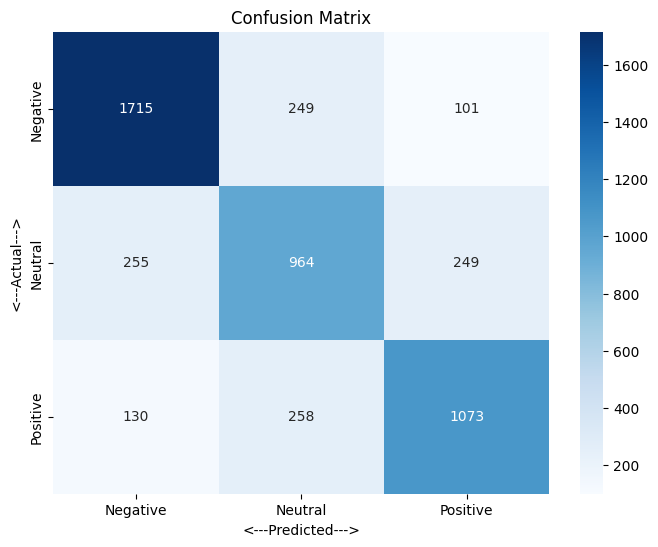

In [ ]:
cm = confusion_matrix(y_test, y_pred_lstm_classes)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('<---Actual--->')
plt.xlabel('<---Predicted--->')
plt.title('Confusion Matrix')
plt.show()

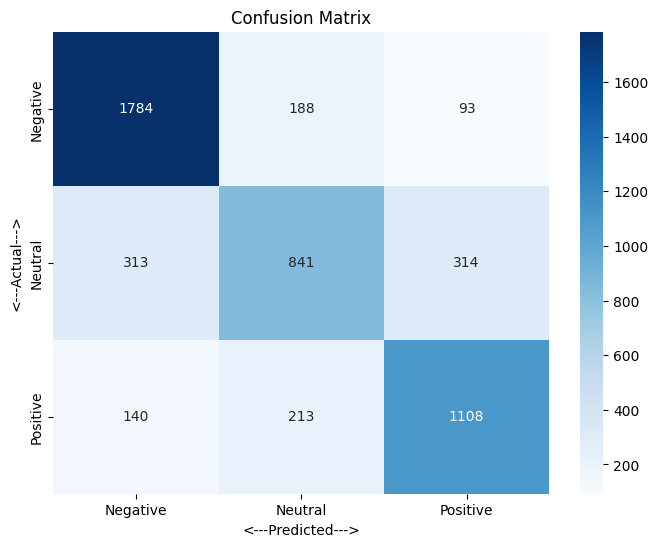

In [ ]:
cm = confusion_matrix(y_test, y_pred_rnn_classes)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('<---Actual--->')
plt.xlabel('<---Predicted--->')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import numpy as np

# Sentiment mapping
class_names = ['negative', 'neutral', 'positive']
N = [0, 1, 2]
reverse_mapping = dict(zip(N, class_names))

# Define weights for each model
weight_lstm = 0.6
weight_rnn = 0.4

# Function to preprocess input for LSTM/RNN
def preprocess_input(text, tokenizer, max_len):
    tokenized_input = tokenizer.texts_to_sequences([text])
    tokenized_input = pad_sequences(tokenized_input, maxlen=max_len)
    return tokenized_input

# Function to preprocess and predict sentiment for LSTM or RNN
def predict_sentiment_for_model(model, tokenizer, text):
    processed_input = preprocess_input(text, tokenizer, max_len)
    prediction = model.predict(processed_input)
    return prediction[0]  # Return scores for all classes

# User input for sentiment prediction
user_input = input("Enter a sentence for sentiment analysis: ")

# Predict sentiment scores for LSTM model
sentiment_scores_lstm = predict_sentiment_for_model(model_lstm, tokenizer, user_input)

# Predict sentiment scores for RNN model
sentiment_scores_rnn = predict_sentiment_for_model(model_rnn, tokenizer, user_input)

# Ensemble by weighted voting
weighted_scores = (sentiment_scores_lstm * weight_lstm) + (sentiment_scores_rnn * weight_rnn)

# Get the final predicted class based on the highest weighted score
final_class = np.argmax(weighted_scores)
final_sentiment = reverse_mapping[final_class]

# Print results
print(f"\nFinal Ensemble Prediction (Weighted Voting): {final_sentiment}")
print(f"Weighted Negative Score: {weighted_scores[0]}")
print(f"Weighted Neutral Score: {weighted_scores[1]}")
print(f"Weighted Positive Score: {weighted_scores[2]}")



Enter a sentence for sentiment analysis: good morning
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Final Ensemble Prediction (Weighted Voting): positive
Weighted Negative Score: 0.06684023141860962
Weighted Neutral Score: 0.15372127294540405
Weighted Positive Score: 0.7794385552406311


In [ ]:
#Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


# Assuming you have predictions from LSTM and RNN models in y_pred_lstm_classes and y_pred_rnn_classes
# and the true labels in y_test

# Combine predictions from LSTM and RNN to create the meta-features
X_meta = np.column_stack((y_pred_lstm_classes, y_pred_rnn_classes))

# Split the meta-data into training and testing sets
X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_meta, y_test, test_size=0.2, random_state=42
)

# Initialize the Gradient Boosting meta-model
meta_model = GradientBoostingClassifier(random_state=42)

# Train the meta-model on the stacked predictions
meta_model.fit(X_meta_train, y_meta_train)

# Make predictions on the test set for the meta-model
y_meta_pred = meta_model.predict(X_meta_test)

# Evaluate the meta-model
meta_accuracy = accuracy_score(y_meta_test, y_meta_pred)
print(f"Meta-Model (Gradient Boosting) Accuracy: {meta_accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_meta_test, y_meta_pred))


Meta-Model (Gradient Boosting) Accuracy: 0.7618

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       450
           1       0.67      0.66      0.66       304
           2       0.76      0.71      0.74       245

    accuracy                           0.76       999
   macro avg       0.75      0.74      0.75       999
weighted avg       0.76      0.76      0.76       999



In [ ]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

# Sentiment mapping
class_names = ['negative', 'neutral', 'positive']
N = [0, 1, 2]
reverse_mapping = dict(zip(N, class_names))

# Function to preprocess input for LSTM/RNN
def preprocess_input_for_model(text, tokenizer, max_len):
    tokenized_input = tokenizer.texts_to_sequences([text])
    tokenized_input = pad_sequences(tokenized_input, maxlen=max_len)
    return tokenized_input

# Predict sentiment for LSTM or RNN model and return probabilities
def predict_sentiment_for_model(model, tokenizer, text, max_len):
    processed_input = preprocess_input_for_model(text, tokenizer, max_len)
    prediction = model.predict(processed_input)  # Get probability for each class
    return prediction[0]  # Returns probabilities for negative, neutral, positive

# Ensemble function to predict sentiment using LSTM and RNN predictions with a meta-model
def predict_sentiment_with_scores(user_input):
    # Preprocess user input for LSTM and RNN
    input_for_lstm = preprocess_input_for_model(user_input, tokenizer_lstm, max_len)
    input_for_rnn = preprocess_input_for_model(user_input, tokenizer_rnn, max_len)

    # Get sentiment scores from each model
    lstm_pred = model_lstm.predict(input_for_lstm)[0]  # LSTM probabilities for classes
    rnn_pred = model_rnn.predict(input_for_rnn)[0]     # RNN probabilities for classes

    # Get predicted classes for LSTM and RNN
    lstm_class = np.argmax(lstm_pred)  # Predicted class from LSTM
    rnn_class = np.argmax(rnn_pred)    # Predicted class from RNN

    # Stack predicted classes from LSTM and RNN as input for meta-model
    meta_input = np.array([lstm_class, rnn_class]).reshape(1, -1)  # Reshape to (1, 2)

    # Predict final sentiment with the meta-model (Gradient Boosting)
    final_prediction = meta_model.predict(meta_input)[0]


    # Get probability scores for the final prediction
    probabilities = meta_model.predict_proba(meta_input)[0]
    sentiment_score = {
        'positive': probabilities[2],  # Index for positive
        'neutral': probabilities[1],   # Index for neutral
        'negative': probabilities[0]   # Index for negative
    }

    # Map prediction to sentiment label
    final_sentiment = reverse_mapping[final_prediction]

    return final_sentiment, sentiment_score

# User input
user_input = input("Please enter a sentence to analyze its sentiment: ")

# Predict final sentiment and scores from ensemble
final_sentiment, sentiment_score = predict_sentiment_with_scores(user_input)

# Output the overall sentiment
print(f"The overall sentiment is: {final_sentiment.capitalize()}")

# Output the sentiment scores from the ensemble method
print("\nSentiment Scores from Ensemble Method:")
for sentiment, score in sentiment_score.items():
    print(f"{sentiment.capitalize()}: {score:.6f}")


Please enter a sentence to analyze its sentiment: good morning
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
The overall sentiment is: Positive

Sentiment Scores from Ensemble Method:
Positive: 0.817464
Neutral: 0.139786
Negative: 0.042749


In [ ]:
!ls /content/drive/MyDrive


'12th Marksheet_Satyaki.pdf'
'18700221023_Satyaki Mukhopadhyay__PPT.pdf'
'18700221027_Sohom Das'
 18700221053
'18700221053 (1)'
'18700221053_ESC 501 (1).pdf'
'18700221053_ESC 501.pdf'
'18700221053_Satyaki Mukhopadhyay'
'18700221053_Satyaki Mukhopadhyay (1)'
'18700221053_Satyaki Mukhopadhyay (1).pdf'
'18700221053_Satyaki Mukhopadhyay_CloudComputing.gdoc'
'18700221053_Satyaki Mukhopadhyay_CyberSecurity (1).pdf'
'18700221053_Satyaki Mukhopadhyay_CyberSecurity.docx'
'18700221053_Satyaki Mukhopadhyay_CyberSecurity.mp4'
'18700221053_Satyaki Mukhopadhyay_CyberSecurity.pdf'
 18700221053_SatyakiMukhopadhyay.docx.pdf
'18700221053_Satyaki Mukhopadhyay_OS.pdf'
'18700221053_Satyaki Mukhopadhyay_OS.pdf.mp4'
'18700221053_Satyaki Mukhopadhyay.pdf'
 18700221053_SatyakiMukhopadhyay.pdf
 18700221053_SatyakiMukhopadhyay_PEC-IT702F.pdf
'18700221053_Satyaki Mukhopadhyay__Report.pdf'
 53
'5th sem fees.pdf'
'Aadhar(FRONT)_Satyaki.jpg'
'Adobe Scan 06-Jan-2022 (1).pdf'
'Adobe Scan 14-Dec-2021.pdf'
'allotment le

In [5]:


from google.colab import files
files.download("Opinion_Mining.ipynb")



FileNotFoundError: Cannot find file: Opinion_Mining.ipynb